## Background

The **Park HyperGoode Projection (PHG)** is an equal-area world projection that combines two different equal-area pseudocylindrical projections.

At low latitudes, PHG uses a modified sinusoidal-type projection. At high latitudes, it transitions to the **Tobler Hyperelliptical Projection**, providing greater control over polar shape and reducing some of the visual drawbacks of the classical Goode Homolosine projection.

The low-latitude component employed here is a one-parameter family of equal-area projections that continuously interpolates between the **Sinusoidal Projection** and the **Cylindrical Equal-Area Projection**. By adjusting a single parameter, the projection can vary smoothly from a pure sinusoidal form to a pure equal-area cylindrical form while preserving area throughout the transition.

Mathematically, the vertical coordinate is defined using a sinusoidal function of latitude, and the horizontal coordinate is derived from the equal-area condition. In its general form,

\[
y \propto \frac{\sin(k\phi)}{k},
\]

with the corresponding \(x\)-coordinate chosen to satisfy the equal-area property.

After discovering the Sinucyli projection family, it appears that this low-latitude projection may be identical, or nearly identical, to one branch of the **Sinucyli Projection**. However, because the original source was not fully available during development, the relationship was not initially known. Therefore, this projection is provisionally described as a sinusoidal-derived equal-area interpolation that is likely equivalent to the Sinucyli projection's sinusoidal branch.

Consequently, the Park HyperGoode Projection may be viewed as a hybrid projection combining:

1. A sinusoidal–cylindrical equal-area interpolation (probably equivalent to Sinucyli), used in low latitudes.
2. The Tobler Hyperelliptical Projection, used in high latitudes.
3. A smooth equal-area transition between the two components.

k        = 2.2
phi0 deg = 35.255432627908
alpha    = 0.699656012803
gamma    = 0.995764011471


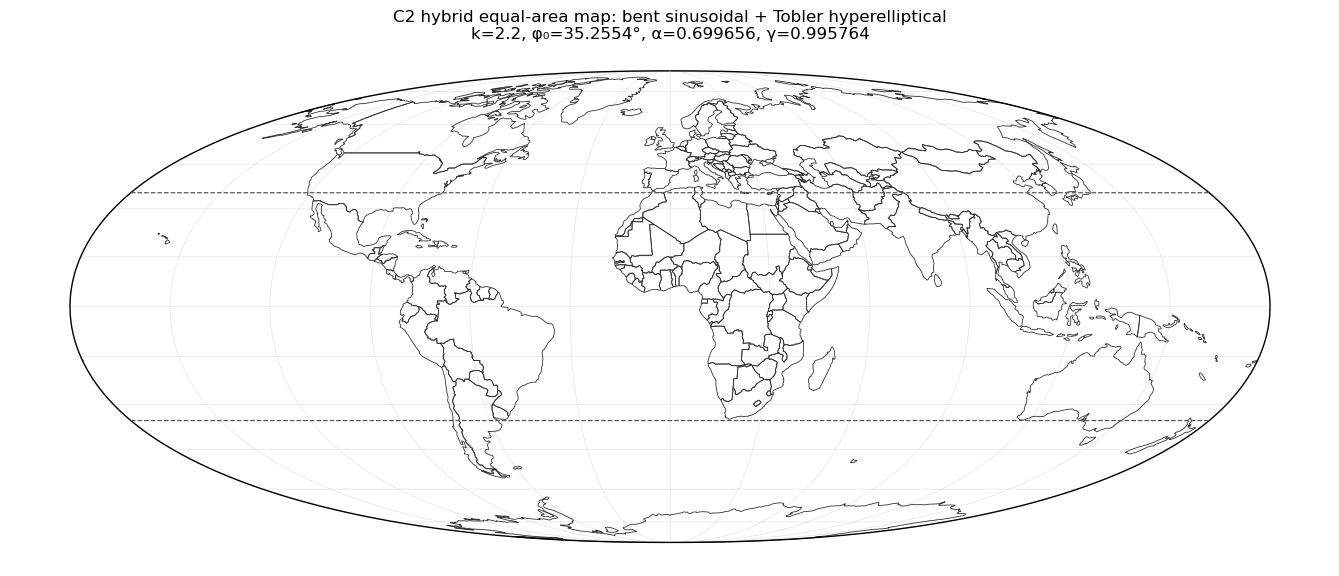

(<Figure size 1350x720 with 1 Axes>,
 <Axes: title={'center': 'C2 hybrid equal-area map: bent sinusoidal + Tobler hyperelliptical\nk=2.2, φ₀=35.2554°, α=0.699656, γ=0.995764'}>)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import geopandas as gpd
from scipy.optimize import brentq
from scipy.special import beta, betaincinv
from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString, GeometryCollection

# ============================================================
# 1. Parameters
# ============================================================

k = 2.2

# ============================================================
# 2. Tobler hyperelliptical helpers
# ============================================================

def I_k(k):
    return beta(1/k, 1 + 1/k) / k

I = I_k(k)

def z_from_phi(phi):
    phi = np.asarray(phi, dtype=float)
    s = np.sign(phi)
    p = np.abs(phi)

    out = np.zeros_like(p)
    mask = p >= 1e-14

    u = betaincinv(1/k, 1 + 1/k, np.sin(p[mask]))
    out[mask] = u ** (1/k)

    return s * out

def B_from_z(z):
    z = np.asarray(z, dtype=float)
    return np.maximum(0.0, 1 - np.abs(z)**k) ** (1/k)

def tobler_B(phi):
    return B_from_z(z_from_phi(phi))

def tobler_log1(phi):
    z = abs(float(z_from_phi(phi)))
    B = float(B_from_z(z))
    if z < 1e-14:
        return 0.0
    return -I * np.cos(phi) * z**(k-1) / B**(k+1)

def tobler_log2(phi):
    h = 1e-5
    return (tobler_log1(phi + h) - tobler_log1(phi - h)) / (2*h)

# ============================================================
# 3. Low-latitude bent sinusoidal
# ============================================================

def y_low(phi, a):
    return phi if abs(a) < 1e-12 else np.sin(a * phi) / a

def yprime_low(phi, a):
    return np.cos(a * phi)

def w_low(phi, a):
    return np.cos(phi) / yprime_low(phi, a)

def L_log1(phi, a):
    return -np.tan(phi) + a * np.tan(a * phi)

def L_log2(phi, a):
    return -1 / np.cos(phi)**2 + a*a / np.cos(a*phi)**2

# ============================================================
# 4. Solve C1 + C2 transition
# ============================================================

def alpha_roots_from_c1(phi):
    amax = (np.pi / 2) / phi * 0.999999
    target = tobler_log1(phi)

    def f(a):
        return L_log1(phi, a) - target

    xs = np.linspace(1e-8, amax, 700)
    vals = np.array([f(x) for x in xs])

    roots = []
    for x1, x2, y1, y2 in zip(xs[:-1], xs[1:], vals[:-1], vals[1:]):
        if np.isfinite(y1) and np.isfinite(y2) and y1 * y2 < 0:
            roots.append(brentq(f, x1, x2))

    return roots

def c2_residual(phi):
    roots = alpha_roots_from_c1(phi)
    if not roots:
        return None
    a = roots[0]
    return L_log2(phi, a) - tobler_log2(phi), a

def solve_transition(k):
    phis = np.deg2rad(np.linspace(0.5, 88.5, 800))
    data = []

    for ph in phis:
        r = c2_residual(ph)
        if r is not None:
            res, a = r
            data.append((ph, a, res))

    for d1, d2 in zip(data[:-1], data[1:]):
        p1, a1, r1 = d1
        p2, a2, r2 = d2

        if r1 * r2 < 0:
            def g(phi):
                return c2_residual(phi)[0]

            phi0 = brentq(g, p1, p2)
            res, alpha = c2_residual(phi0)
            return phi0, alpha

    raise RuntimeError(f"No internal C2 solution found for k={k}")

phi0, alpha = solve_transition(k)

gamma = w_low(phi0, alpha) / float(tobler_B(phi0))
z0 = float(z_from_phi(phi0))
Yt0 = z0 / (gamma * I)
shift = y_low(phi0, alpha) - Yt0

print(f"k        = {k}")
print(f"phi0 deg = {np.rad2deg(phi0):.12f}")
print(f"alpha    = {alpha:.12f}")
print(f"gamma    = {gamma:.12f}")

# ============================================================
# 5. Combined projection: lon/lat degrees -> x/y
# ============================================================

def project_lonlat(lon_deg, lat_deg):
    lon = np.deg2rad(np.asarray(lon_deg, dtype=float))
    phi = np.deg2rad(np.asarray(lat_deg, dtype=float))

    sgn = np.sign(phi)
    p = np.abs(phi)

    x = np.empty_like(phi, dtype=float)
    y = np.empty_like(phi, dtype=float)

    low = p <= phi0
    high = ~low

    if np.any(low):
        w = w_low(p[low], alpha)
        yy = y_low(p[low], alpha)
        x[low] = lon[low] * w
        y[low] = sgn[low] * yy

    if np.any(high):
        z = z_from_phi(p[high])
        B = B_from_z(z)
        w = gamma * B
        yy = z / (gamma * I) + shift
        x[high] = lon[high] * w
        y[high] = sgn[high] * yy

    return x, y

# ============================================================
# 6. Geometry helpers
# ============================================================

def split_ring_at_dateline(coords):
    segments = []
    current = [coords[0]]
    prev_lon = coords[0][0]

    for pt in coords[1:]:
        lon = pt[0]
        if abs(lon - prev_lon) > 180:
            if len(current) >= 2:
                segments.append(current)
            current = [pt]
        else:
            current.append(pt)
        prev_lon = lon

    if len(current) >= 2:
        segments.append(current)

    return segments

def densify_coords(coords, max_step=0.5):
    out = []

    for (lon1, lat1), (lon2, lat2) in zip(coords[:-1], coords[1:]):
        out.append((lon1, lat1))
        n = int(max(abs(lon2-lon1), abs(lat2-lat1)) // max_step)

        for j in range(1, n+1):
            f = j / (n+1)
            out.append((lon1 + f*(lon2-lon1), lat1 + f*(lat2-lat1)))

    out.append(coords[-1])
    return out

def projected_segments_from_geom(geom,
    project_func=project_lonlat):
    segments = []

    if isinstance(geom, Polygon):
        rings = [geom.exterior] + list(geom.interiors)

        for ring in rings:
            coords = list(ring.coords)
            for part in split_ring_at_dateline(coords):
                dense = densify_coords(part)
                lon = np.array([p[0] for p in dense])
                lat = np.array([p[1] for p in dense])
                x, y = project_lonlat(lon, lat)
                segments.append(np.column_stack([x, y]))

    elif isinstance(geom, MultiPolygon):
        for g in geom.geoms:
            segments.extend(projected_segments_from_geom(g))

    elif isinstance(geom, LineString):
        coords = list(geom.coords)
        for part in split_ring_at_dateline(coords):
            dense = densify_coords(part)
            lon = np.array([p[0] for p in dense])
            lat = np.array([p[1] for p in dense])
            x, y = project_lonlat(lon, lat)
            segments.append(np.column_stack([x, y]))

    elif isinstance(geom, MultiLineString):
        for g in geom.geoms:
            segments.extend(projected_segments_from_geom(g))

    elif isinstance(geom, GeometryCollection):
        for g in geom.geoms:
            segments.extend(projected_segments_from_geom(g))

    return segments

# ============================================================
# 7. Segment builders
# ============================================================

def build_coast_segments():
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)

    coast_segments = []
    for geom in world.geometry:
        coast_segments.extend(projected_segments_from_geom(geom))

    return coast_segments

def build_graticule_segments():
    segments = []

    for lon in range(-180, 181, 30):
        lats = np.linspace(-89.999, 89.999, 900)
        lons = np.full_like(lats, lon)
        x, y = project_lonlat(lons, lats)
        segments.append(np.column_stack([x, y]))

    for lat in range(-75, 76, 15):
        lons = np.linspace(-180, 180, 1400)
        lats = np.full_like(lons, lat)
        x, y = project_lonlat(lons, lats)
        segments.append(np.column_stack([x, y]))

    return segments

def build_boundary_segments():
    segments = []

    for lat in [89.999, -89.999]:
        lons = np.linspace(-180, 180, 1500)
        lats = np.full_like(lons, lat)
        x, y = project_lonlat(lons, lats)
        segments.append(np.column_stack([x, y]))

    for lon in [-180, 180]:
        lats = np.linspace(-89.999, 89.999, 1500)
        lons = np.full_like(lats, lon)
        x, y = project_lonlat(lons, lats)
        segments.append(np.column_stack([x, y]))

    return segments

def build_transition_segments():
    segments = []

    for lat in [np.rad2deg(phi0), -np.rad2deg(phi0)]:
        lons = np.linspace(-180, 180, 1400)
        lats = np.full_like(lons, lat)
        x, y = project_lonlat(lons, lats)
        segments.append(np.column_stack([x, y]))

    return segments

# ============================================================
# 8. Plot
# ============================================================

def plot_hybrid_map(
    show_transition=True,
    figsize=(13.5, 7.2),
    save_path=None,
    dpi=250,
):
    coast_segments = build_coast_segments()
    grat_segments = build_graticule_segments()
    boundary_segments = build_boundary_segments()

    fig, ax = plt.subplots(figsize=figsize)

    ax.add_collection(LineCollection(
        grat_segments,
        linewidths=0.45,
        alpha=0.45,
        colors="0.75",
    ))

    ax.add_collection(LineCollection(
        coast_segments,
        linewidths=0.6,
        colors="0.20",
    ))

    ax.add_collection(LineCollection(
        boundary_segments,
        linewidths=1.0,
        colors="black",
    ))

    if show_transition:
        ax.add_collection(LineCollection(
            build_transition_segments(),
            linewidths=0.9,
            linestyles="--",
            colors="0.35",
        ))

    ax.set_aspect("equal", adjustable="box")
    ax.autoscale()
    ax.axis("off")

    ax.set_title(
        f"C2 hybrid equal-area map: bent sinusoidal + Tobler hyperelliptical\n"
        f"k={k}, φ₀={np.rad2deg(phi0):.4f}°, α={alpha:.6f}, γ={gamma:.6f}"
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

    return fig, ax

plot_hybrid_map(show_transition=True)

In [2]:
def plot_hybrid_graticule_only(
    show_transition=True,
    figsize=(13.5, 7.2),
    save_path=None,
    dpi=250,
):
    grat_segments = build_graticule_segments()
    boundary_segments = build_boundary_segments()

    fig, ax = plt.subplots(figsize=figsize)

    ax.add_collection(LineCollection(
        grat_segments,
        linewidths=0.55,
        alpha=0.75,
        colors="0.35",
    ))

    ax.add_collection(LineCollection(
        boundary_segments,
        linewidths=1.1,
        colors="black",
    ))

    if show_transition:
        ax.add_collection(LineCollection(
            build_transition_segments(),
            linewidths=1.0,
            linestyles="--",
            colors="0.15",
        ))

    ax.set_aspect("equal", adjustable="box")
    ax.autoscale()
    ax.axis("off")

    ax.set_title(
        f"Graticule-only C2 hybrid map\n"
        f"k={k}, φ₀={np.rad2deg(phi0):.4f}°, α={alpha:.6f}, γ={gamma:.6f}"
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

    return fig, ax

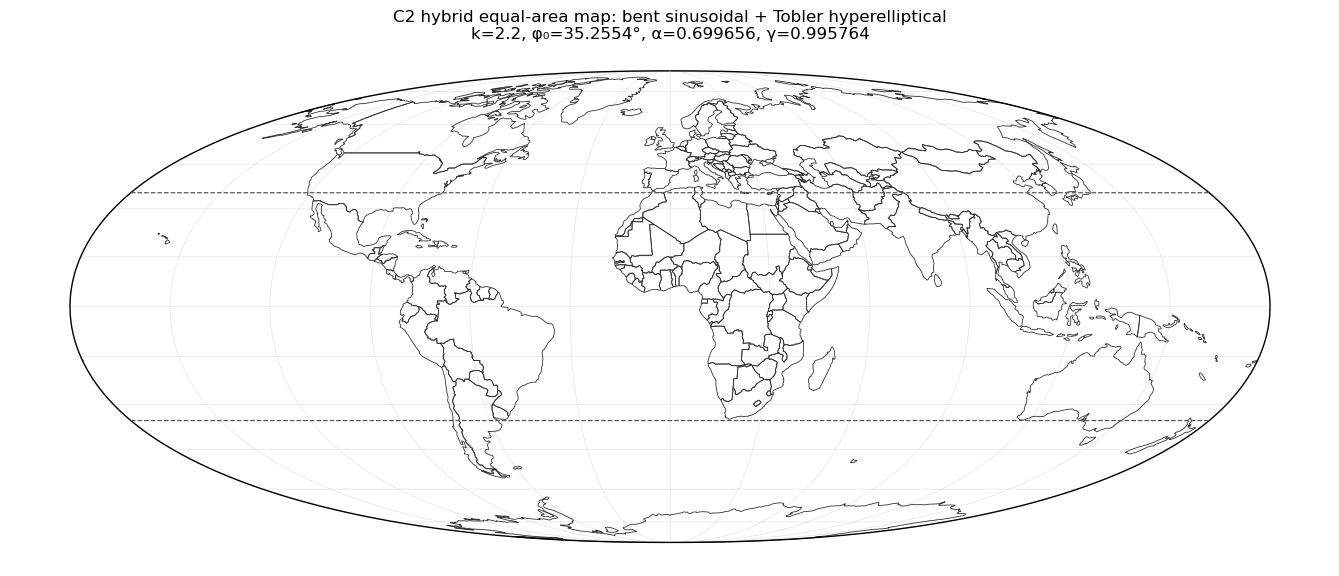

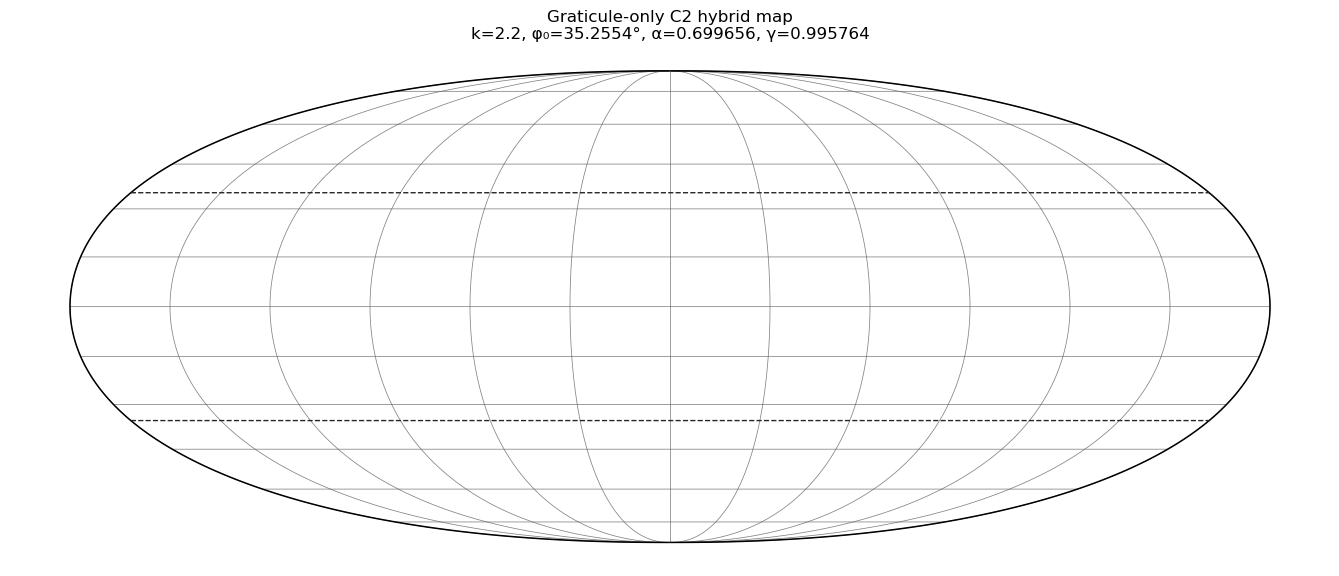

(<Figure size 1350x720 with 1 Axes>,
 <Axes: title={'center': 'Graticule-only C2 hybrid map\nk=2.2, φ₀=35.2554°, α=0.699656, γ=0.995764'}>)

In [3]:
plot_hybrid_map(show_transition=True)
plot_hybrid_graticule_only(show_transition=True)

C2 solution found for k=2.2
phi0 deg = 35.255432627908
alpha    = 0.699656012803
gamma    = 0.995764011471


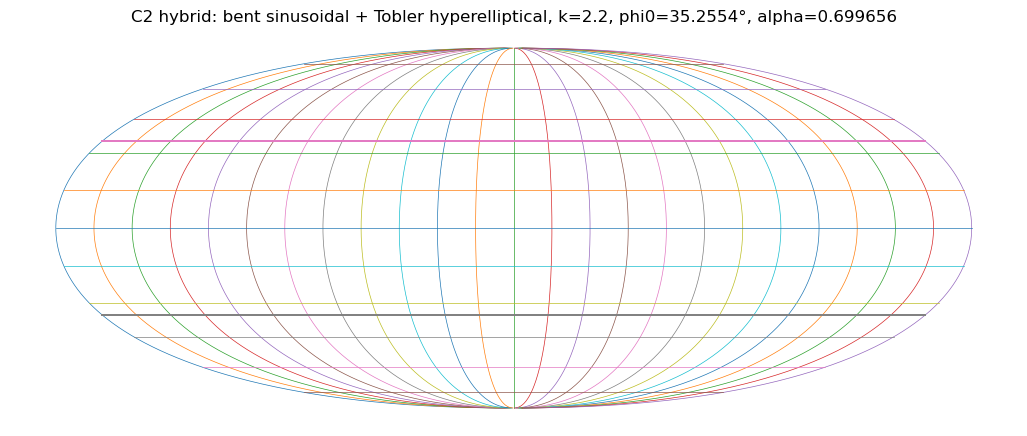

equator width = 6.283185307180
total height  = 2.469027706684
aspect ratio  = 2.544801457744
Mollweide AR  = 3.141592653590
AR / pi       = 0.810035462375


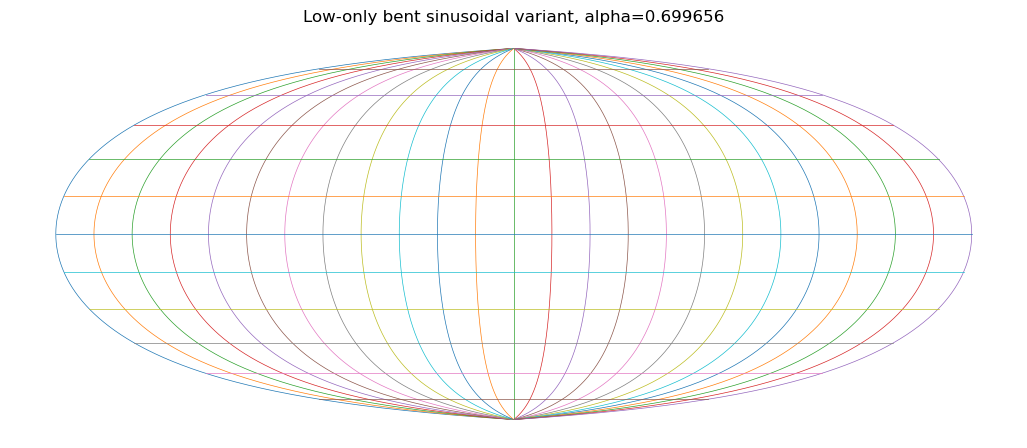

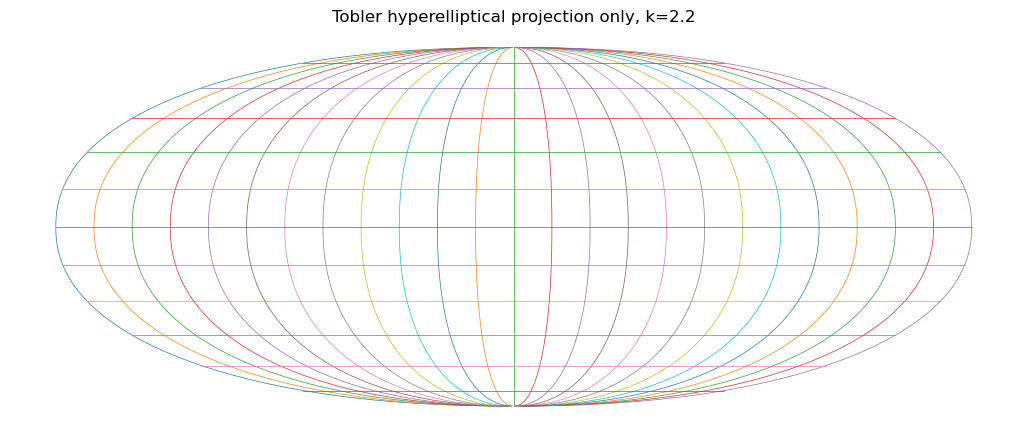

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import beta, betaincinv

# -----------------------------
# Choose Tobler superellipse k
# -----------------------------
k = 2.2  # try 1.8, 2.0, 2.5, 3.0

# -----------------------------
# Tobler hyperelliptical helpers
# A(z) / I = sin(phi)
# A(z)=int_0^z (1-t^k)^(1/k) dt
# -----------------------------
def I_k(k):
    return beta(1/k, 1 + 1/k) / k

I = I_k(k)

def z_from_phi(phi):
    p = abs(phi)
    if p < 1e-14:
        return 0.0
    u = betaincinv(1/k, 1 + 1/k, np.sin(p))
    z = u ** (1/k)
    return np.sign(phi) * z

def B_from_z(z):
    return max(0.0, 1 - abs(z)**k) ** (1/k)

def tobler_B(phi):
    return B_from_z(z_from_phi(phi))

def tobler_log1(phi):
    z = abs(z_from_phi(phi))
    B = B_from_z(z)
    if z < 1e-14:
        return 0.0
    return -I * np.cos(phi) * z**(k-1) / B**(k+1)

def tobler_log2(phi):
    h = 1e-5
    return (tobler_log1(phi + h) - tobler_log1(phi - h)) / (2*h)

# -----------------------------
# Low-latitude bent sinusoidal
# Y' = cos(alpha phi)
# w = cos(phi) / cos(alpha phi)
# -----------------------------
def y_low(phi, a):
    if abs(a) < 1e-12:
        return phi
    return np.sin(a * phi) / a

def yprime_low(phi, a):
    return np.cos(a * phi)

def w_low(phi, a):
    return np.cos(phi) / yprime_low(phi, a)

def L_log1(phi, a):
    return -np.tan(phi) + a * np.tan(a * phi)

def L_log2(phi, a):
    return -1 / np.cos(phi)**2 + a*a / np.cos(a*phi)**2

# -----------------------------
# For each phi, solve C1 for alpha.
# Then scan C2 residual.
# -----------------------------
def alpha_roots_from_c1(phi):
    amax = (np.pi/2) / phi * 0.999999
    target = tobler_log1(phi)

    def f(a):
        return L_log1(phi, a) - target

    xs = np.linspace(1e-8, amax, 700)
    vals = np.array([f(x) for x in xs])

    roots = []
    for x1, x2, y1, y2 in zip(xs[:-1], xs[1:], vals[:-1], vals[1:]):
        if np.isfinite(y1) and np.isfinite(y2) and y1 * y2 < 0:
            roots.append(brentq(f, x1, x2))

    return roots

def c2_residual(phi):
    roots = alpha_roots_from_c1(phi)
    if not roots:
        return None
    a = roots[0]
    return L_log2(phi, a) - tobler_log2(phi), a

phis = np.deg2rad(np.linspace(0.5, 88.5, 800))
data = []

for ph in phis:
    r = c2_residual(ph)
    if r is not None:
        res, a = r
        data.append((ph, a, res))

solution = None

for d1, d2 in zip(data[:-1], data[1:]):
    p1, a1, r1 = d1
    p2, a2, r2 = d2

    if r1 * r2 < 0:
        def g(phi):
            r = c2_residual(phi)
            return r[0]

        phi0 = brentq(g, p1, p2)
        res, alpha = c2_residual(phi0)
        solution = phi0, alpha
        break

if solution is None:
    print(f"No internal C2 solution found for k={k}.")
    best = min(data, key=lambda t: abs(t[2]))
    print("Closest approach:")
    print("phi0 deg =", np.rad2deg(best[0]))
    print("alpha    =", best[1])
    print("residual =", best[2])

    plt.figure(figsize=(8, 4))
    plt.plot([np.rad2deg(d[0]) for d in data], [d[2] for d in data])
    plt.axhline(0, linewidth=0.8)
    plt.xlabel("transition latitude φ₀, degrees")
    plt.ylabel("C2 residual")
    plt.title(f"C2 residual along C1 curve, k={k}")
    plt.show()

else:
    phi0, alpha = solution

    # Width matching determines gamma
    gamma = w_low(phi0, alpha) / tobler_B(phi0)

    # y-shift for continuity
    z0 = z_from_phi(phi0)
    Yt0 = z0 / (gamma * I)
    shift = y_low(phi0, alpha) - Yt0

    print(f"C2 solution found for k={k}")
    print(f"phi0 deg = {np.rad2deg(phi0):.12f}")
    print(f"alpha    = {alpha:.12f}")
    print(f"gamma    = {gamma:.12f}")

    def project(lon, lat):
        phi = lat
        lam = lon

        sgn = np.sign(phi)
        p = abs(phi)

        if p <= phi0:
            w = w_low(p, alpha)
            y = y_low(p, alpha)
        else:
            z = z_from_phi(p)
            B = B_from_z(z)
            w = gamma * B
            y = z / (gamma * I) + shift

        return lam * w, sgn * y

    fig, ax = plt.subplots(figsize=(13, 7))

    for lon_deg in range(-180, 181, 15):
        lats = np.deg2rad(np.linspace(-89.9, 89.9, 600))
        lons = np.deg2rad(np.full_like(lats, lon_deg))
        xy = np.array([project(lon, lat) for lon, lat in zip(lons, lats)])
        ax.plot(xy[:, 0], xy[:, 1], linewidth=0.5)

    for lat_deg in range(-75, 76, 15):
        lons = np.deg2rad(np.linspace(-180, 180, 800))
        lats = np.deg2rad(np.full_like(lons, lat_deg))
        xy = np.array([project(lon, lat) for lon, lat in zip(lons, lats)])
        ax.plot(xy[:, 0], xy[:, 1], linewidth=0.5)

    for lat_deg in [np.rad2deg(phi0), -np.rad2deg(phi0)]:
        lons = np.deg2rad(np.linspace(-180, 180, 800))
        lats = np.deg2rad(np.full_like(lons, lat_deg))
        xy = np.array([project(lon, lat) for lon, lat in zip(lons, lats)])
        ax.plot(xy[:, 0], xy[:, 1], linewidth=1.4)

    ax.set_aspect("equal")
    ax.set_title(
        f"C2 hybrid: bent sinusoidal + Tobler hyperelliptical, "
        f"k={k}, phi0={np.rad2deg(phi0):.4f}°, alpha={alpha:.6f}"
    )
    ax.axis("off")
    plt.show()

# Width, height, aspect ratio
equator_width = 2 * np.pi * w_low(0.0, alpha)

z_pole = z_from_phi(np.pi / 2)
B_pole = B_from_z(z_pole)

y_pole = z_pole / (gamma * I) + shift
total_height = 2 * y_pole

aspect_ratio = equator_width / total_height



# ============================================================
# Extra plots:
# 1) Low-latitude bent sinusoidal variant alone, same alpha
# 2) Tobler hyperelliptical projection alone, same k
# ============================================================

if solution is not None:
    print(f"equator width = {equator_width:.12f}")
    print(f"total height  = {total_height:.12f}")
    print(f"aspect ratio  = {aspect_ratio:.12f}")
    print(f"Mollweide AR  = {np.pi:.12f}")
    print(f"AR / pi       = {aspect_ratio / np.pi:.12f}")
    # -----------------------------
    # 1. Bent sinusoidal variant alone
    # -----------------------------
    def project_low_only(lon, lat):
        phi = lat
        lam = lon
        w = w_low(phi, alpha)
        y = y_low(phi, alpha)
        return lam * w, y

    fig, ax = plt.subplots(figsize=(13, 7))

    for lon_deg in range(-180, 181, 15):
        lats = np.deg2rad(np.linspace(-89.9, 89.9, 600))
        lons = np.deg2rad(np.full_like(lats, lon_deg))
        xy = np.array([project_low_only(lon, lat) for lon, lat in zip(lons, lats)])
        ax.plot(xy[:, 0], xy[:, 1], linewidth=0.5)

    for lat_deg in range(-75, 76, 15):
        lons = np.deg2rad(np.linspace(-180, 180, 800))
        lats = np.deg2rad(np.full_like(lons, lat_deg))
        xy = np.array([project_low_only(lon, lat) for lon, lat in zip(lons, lats)])
        ax.plot(xy[:, 0], xy[:, 1], linewidth=0.5)

    ax.set_aspect("equal")
    ax.set_title(
        f"Low-only bent sinusoidal variant, "
        f"alpha={alpha:.6f}"
    )
    ax.axis("off")
    plt.show()


    # -----------------------------
    # 2. Tobler hyperelliptical projection alone, same k
    # -----------------------------
    # Use the standard normalization gamma = 1,
    # so x = lambda B(z), y = z / I.
    def project_tobler_only(lon, lat):
        phi = lat
        lam = lon

        z = z_from_phi(phi)
        B = B_from_z(z)

        x = lam * B
        y = z / I
        return x, y

    fig, ax = plt.subplots(figsize=(13, 7))

    for lon_deg in range(-180, 181, 15):
        lats = np.deg2rad(np.linspace(-89.9, 89.9, 600))
        lons = np.deg2rad(np.full_like(lats, lon_deg))
        xy = np.array([project_tobler_only(lon, lat) for lon, lat in zip(lons, lats)])
        ax.plot(xy[:, 0], xy[:, 1], linewidth=0.5)

    for lat_deg in range(-75, 76, 15):
        lons = np.deg2rad(np.linspace(-180, 180, 800))
        lats = np.deg2rad(np.full_like(lons, lat_deg))
        xy = np.array([project_tobler_only(lon, lat) for lon, lat in zip(lons, lats)])
        ax.plot(xy[:, 0], xy[:, 1], linewidth=0.5)

    ax.set_aspect("equal")
    ax.set_title(
        f"Tobler hyperelliptical projection only, "
        f"k={k}"
    )
    ax.axis("off")
    plt.show()

In [7]:
# ============================================================
# Goode-style interruption wrapper
# ============================================================

def goode_lobe_center(lon_deg, lat_deg):
    """
    Goode Homolosine-style lobe centers.
    Northern hemisphere:
        Americas centered at -100
        Eurasia/Africa centered at 30
    Southern hemisphere:
        South America centered at -60
        Africa centered at 20
        Australia/Oceania centered at 140
    """
    lon = np.asarray(lon_deg, dtype=float)
    lat = np.asarray(lat_deg, dtype=float)

    center = np.empty_like(lon)

    north = lat >= 0

    # Northern lobes
    center[north & (lon < -40)] = -100
    center[north & (lon >= -40)] = 30

    # Southern lobes
    center[(~north) & (lon < -20)] = -60
    center[(~north) & (lon >= -20) & (lon < 80)] = 20
    center[(~north) & (lon >= 80)] = 140

    return center


def wrap_to_180(lon):
    return ((lon + 180) % 360) - 180


def project_lonlat_interrupted(lon_deg, lat_deg):
    lon = np.asarray(lon_deg, dtype=float)
    lat = np.asarray(lat_deg, dtype=float)

    center = goode_lobe_center(lon, lat)
    local_lon = wrap_to_180(lon - center)

    x, y = project_lonlat(local_lon, lat)

    # 각 엽을 실제 중앙경선 위치만큼 수평 배치
    # 같은 위도에서 x = lambda * width 이므로 center를 다시 더해줌
    cx, _ = project_lonlat(center, lat)
    return x + cx, y

In [9]:
def projected_segments_from_geom(geom, project_func):
    segments = []

    if isinstance(geom, Polygon):
        rings = [geom.exterior] + list(geom.interiors)

        for ring in rings:
            coords = list(ring.coords)
            for part in split_ring_at_dateline(coords):
                dense = densify_coords(part)
                lon = np.array([p[0] for p in dense])
                lat = np.array([p[1] for p in dense])
                x, y = project_func(lon, lat)
                segments.append(np.column_stack([x, y]))

    elif isinstance(geom, MultiPolygon):
        for g in geom.geoms:
            segments.extend(projected_segments_from_geom(g, project_func))

    elif isinstance(geom, LineString):
        coords = list(geom.coords)
        for part in split_ring_at_dateline(coords):
            dense = densify_coords(part)
            lon = np.array([p[0] for p in dense])
            lat = np.array([p[1] for p in dense])
            x, y = project_func(lon, lat)
            segments.append(np.column_stack([x, y]))

    elif isinstance(geom, MultiLineString):
        for g in geom.geoms:
            segments.extend(projected_segments_from_geom(g, project_func))

    elif isinstance(geom, GeometryCollection):
        for g in geom.geoms:
            segments.extend(projected_segments_from_geom(g, project_func))

    return segments

In [11]:
def plot_hybrid_map_interrupted(
    show_transition=True,
    figsize=(13.5, 7.2),
    save_path=None,
    dpi=250,
):
    coast_segments = build_coast_segments(project_lonlat_interrupted)
    grat_segments = build_graticule_segments(project_lonlat_interrupted)
    boundary_segments = build_boundary_segments(project_lonlat_interrupted)

    fig, ax = plt.subplots(figsize=figsize)

    ax.add_collection(LineCollection(
        grat_segments,
        linewidths=0.45,
        alpha=0.45,
        colors="0.75",
    ))

    ax.add_collection(LineCollection(
        coast_segments,
        linewidths=0.6,
        colors="0.20",
    ))

    ax.add_collection(LineCollection(
        boundary_segments,
        linewidths=1.0,
        colors="black",
    ))

    if show_transition:
        ax.add_collection(LineCollection(
            build_transition_segments(project_lonlat_interrupted),
            linewidths=0.9,
            linestyles="--",
            colors="0.35",
        ))

    ax.set_aspect("equal", adjustable="box")
    ax.autoscale()
    ax.axis("off")

    ax.set_title(
        f"Interrupted C2 hybrid equal-area map\n"
        f"k={k}, φ₀={np.rad2deg(phi0):.4f}°, α={alpha:.6f}, γ={gamma:.6f}"
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

    return fig, ax

In [21]:
# -----------------------------
# Interrupted C2 hybrid plot function
# -----------------------------

_WORLD_CACHE = None

def get_world():
    global _WORLD_CACHE
    if _WORLD_CACHE is None:
        url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
        _WORLD_CACHE = gpd.read_file(url)
    return _WORLD_CACHE


NORTH = [(-180, -40, -100), (-40, 180, 30)]
SOUTH = [(-180, -100, -160), (-100, -20, -60), (-20, 80, 20), (80, 180, 140)]
EQUATOR = (-180, 180, 0)

def norm_lon(lon):
    return ((lon + 180) % 360) - 180

def rel_lon(lon, lon0):
    return ((lon - lon0 + 180) % 360) - 180


def plot_hybrid_interrupted(
    display_mode="general",
    show_caption=True,
    show_transition=True,
    show_outline=True,

    graticule_color="0.75",
    coastline_color="0.20",
    boundary_color="black",
    transition_color="0.35",

    graticule_alpha=0.75,
    transition_alpha=0.85,

    figsize=(12.5, 6.8),
    dpi=None,
    save_path=None,
):

    def choose_lobe(lon, lat):
        lon = norm_lon(lon)

        if abs(lat) < 1e-10:
            lo, hi, lon0 = EQUATOR
            return ("E", 0, lo, hi, lon0)

        lobes = NORTH if lat > 0 else SOUTH
        hemi = "N" if lat > 0 else "S"

        for i, (lo, hi, lon0) in enumerate(lobes):
            if lo <= lon <= hi:
                return (hemi, i, lo, hi, lon0)

        lo, hi, lon0 = lobes[0]
        return (hemi, 0, lo, hi, lon0)

    def project(lon, lat, forced_lobe=None):
        lobe = forced_lobe if forced_lobe is not None else choose_lobe(lon, lat)
        hemi, i, lo, hi, lon0 = lobe

        local_lon = rel_lon(norm_lon(lon), lon0)

        x_arr, y_arr = project_lonlat(
            np.array([local_lon], dtype=float),
            np.array([lat], dtype=float)
        )

        # Goode식: 각 엽의 중심경선을 x축상 실제 lon0 위치에 배치
        x = float(x_arr[0]) + np.deg2rad(lon0)
        y = float(y_arr[0])

        return x, y, (hemi, i)

    def densify(p0, p1, step=0.30):
        lon0, lat0 = p0
        lon1, lat1 = p1

        dlon = lon1 - lon0
        if abs(dlon) > 180:
            lon1 -= 360 * np.sign(dlon)

        n = max(1, int(np.ceil(max(abs(lon1-lon0), abs(lat1-lat0)) / step)))

        return [
            (
                norm_lon(lon0 + (lon1-lon0) * k / n),
                lat0 + (lat1-lat0) * k / n,
            )
            for k in range(n)
        ]

    def polyline_segments(points):
        segs, cur, prev_key = [], [], None

        for lon, lat in points:
            x, y, key = project(lon, lat)

            if prev_key is not None and key != prev_key:
                if len(cur) >= 2:
                    segs.append(np.array(cur))
                cur = []

            cur.append((x, y))
            prev_key = key

        if len(cur) >= 2:
            segs.append(np.array(cur))

        return segs

    def ring_segments(coords):
        coords = list(coords)
        dense = []

        for p0, p1 in zip(coords[:-1], coords[1:]):
            dense.extend(densify(p0, p1))

        dense.append(coords[-1])
        return polyline_segments(dense)

    def geom_segments(geom):
        segs = []

        if isinstance(geom, Polygon):
            segs.extend(ring_segments(geom.exterior.coords))
            for interior in geom.interiors:
                segs.extend(ring_segments(interior.coords))

        elif isinstance(geom, MultiPolygon):
            for poly in geom.geoms:
                segs.extend(geom_segments(poly))

        elif isinstance(geom, GeometryCollection):
            for g in geom.geoms:
                segs.extend(geom_segments(g))

        return segs

    def build_world_segments():
        world = get_world()
        segs = []

        for geom in world.geometry:
            segs.extend(geom_segments(geom))

        return segs

    def build_graticule_segments():
        segs = []

        for lat in range(-80, 81, 20):
            lons = np.linspace(-180, 180, 1201)

            if lat == 0:
                forced = ("E", 0, *EQUATOR)
                pts = []

                for lon in lons:
                    x, y, _ = project(lon, lat, forced_lobe=forced)
                    pts.append((x, y))

                segs.append(np.array(pts))
            else:
                segs.extend(polyline_segments([(lon, lat) for lon in lons]))

        for lon in range(-180, 181, 30):
            lats = np.linspace(-90, 90, 1201)
            segs.extend(polyline_segments([(lon, lat) for lat in lats]))

        return segs

    def build_transition_segments():
        segs = []

        lat0 = np.rad2deg(phi0)

        for lat in [lat0, -lat0]:
            lons = np.linspace(-180, 180, 1201)
            segs.extend(polyline_segments([(lon, lat) for lon in lons]))

        return segs

    def lobe_boundary(hemi, i, lo, hi, lon0, eps=0):
        lat_min, lat_max = (eps, 90) if hemi == "N" else (-90, -eps)
        forced = (hemi, i, lo, hi, lon0)

        pieces = []
        lat_edge = lat_max if hemi == "N" else lat_min

        pts = []
        for lon in np.linspace(lo, hi, 600):
            x, y, _ = project(lon, lat_edge, forced_lobe=forced)
            pts.append((x, y))
        pieces.append(np.array(pts))

        for lon in [lo, hi]:
            pts = []
            for lat in np.linspace(lat_min, lat_max, 600):
                x, y, _ = project(lon, lat, forced_lobe=forced)
                pts.append((x, y))
            pieces.append(np.array(pts))

        return pieces

    def build_outline_segments():
        segs = []

        for i, (lo, hi, lon0) in enumerate(NORTH):
            segs.extend(lobe_boundary("N", i, lo, hi, lon0))

        for i, (lo, hi, lon0) in enumerate(SOUTH):
            segs.extend(lobe_boundary("S", i, lo, hi, lon0))

        return segs

    coast_segments = build_world_segments()
    graticule_segments = build_graticule_segments()

    fig, ax = plt.subplots(figsize=figsize)

    ax.add_collection(LineCollection(
        graticule_segments,
        linewidths=0.45,
        colors=graticule_color,
        alpha=graticule_alpha,
        zorder=1,
    ))

    ax.add_collection(LineCollection(
        coast_segments,
        linewidths=0.50,
        colors=coastline_color,
        zorder=2,
    ))

    if show_transition:
        ax.add_collection(LineCollection(
            build_transition_segments(),
            linewidths=0.85,
            linestyles="--",
            colors=transition_color,
            alpha=transition_alpha,
            zorder=3,
        ))

    if show_outline:
        ax.add_collection(LineCollection(
            build_outline_segments(),
            linewidths=1.0,
            colors=boundary_color,
            zorder=10,
        ))

    ax.set_aspect("equal", adjustable="box")
    ax.autoscale()
    ax.axis("off")

    if display_mode != "plain":
        ax.set_title(
            f"Interrupted C2 hybrid equal-area world map\n"
            f"bent sinusoidal + Tobler hyperelliptical, "
            f"k={k}, φ₀={np.rad2deg(phi0):.4f}°, α={alpha:.6f}"
        )

    if show_caption:
        fig.text(
            0.5,
            0.02,
            rf"$k={k},\ \phi_0={np.rad2deg(phi0):.4f}^\circ,\ "
            rf"\alpha={alpha:.6f},\ \gamma={gamma:.6f}$",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout(rect=[0, 0.05, 1, 1])

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi or 250, bbox_inches="tight")

    plt.show()

    return fig, ax

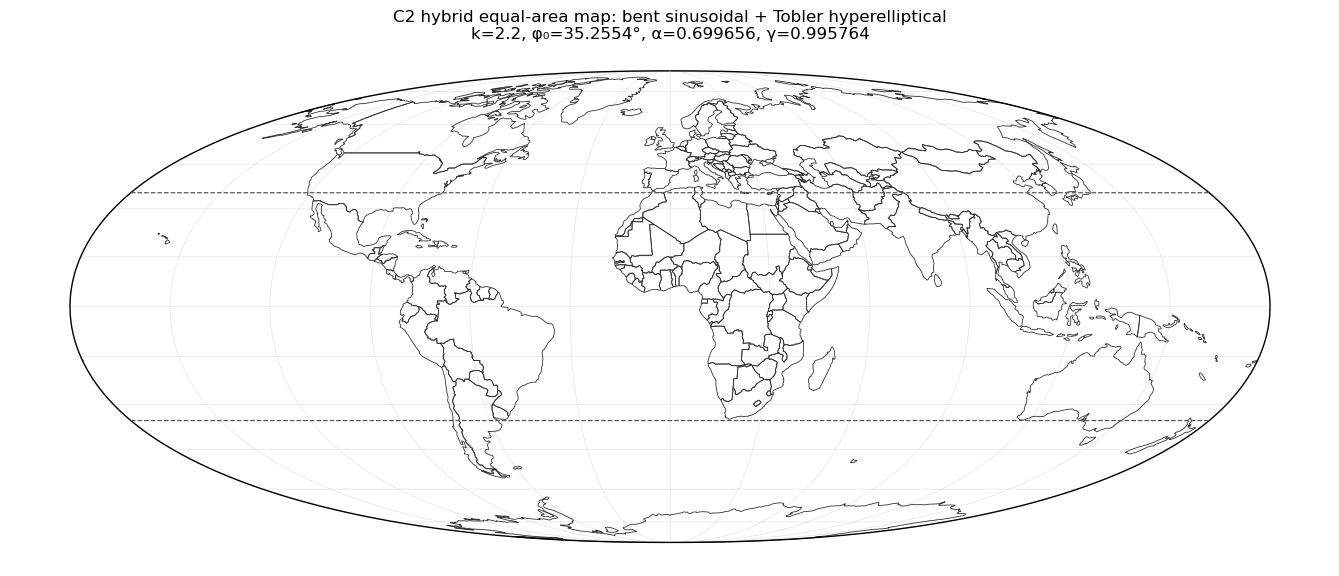

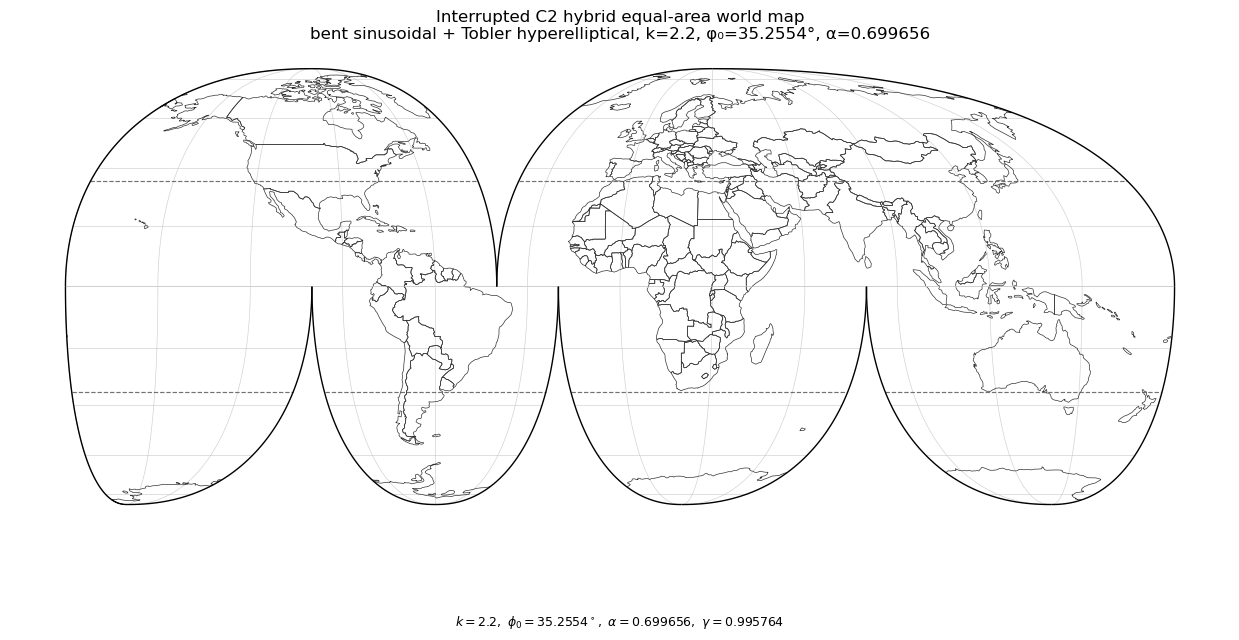

(<Figure size 1250x680 with 1 Axes>,
 <Axes: title={'center': 'Interrupted C2 hybrid equal-area world map\nbent sinusoidal + Tobler hyperelliptical, k=2.2, φ₀=35.2554°, α=0.699656'}>)

In [23]:
plot_hybrid_map(show_transition=True)
plot_hybrid_interrupted(show_transition=True)